In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib


In [66]:
df = pd.read_csv('Health_Insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [68]:
df = df.rename(columns=lambda x: x.strip().title())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1338 non-null   int64  
 1   Sex       1338 non-null   str    
 2   Bmi       1338 non-null   float64
 3   Children  1338 non-null   int64  
 4   Smoker    1338 non-null   str    
 5   Region    1338 non-null   str    
 6   Charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [69]:
# Removing leading & trailing spaces from data
df = df.apply(lambda x: x.str.strip().str.title() if x.dtype == "str" else x)

In [70]:
df['Region'] = df['Region'].replace({'Northeast': 'NorthEast', 'Northwest': 'NorthWest', 'Southeast': 'SouthEast', 'Southwest': 'SouthWest'})
df['Region'].value_counts()

Region
SouthEast    364
SouthWest    325
NorthWest    325
NorthEast    324
Name: count, dtype: int64

In [71]:
df.isnull().sum()

Age         0
Sex         0
Bmi         0
Children    0
Smoker      0
Region      0
Charges     0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(1)

In [73]:
df.drop_duplicates()

,Age,Sex,Bmi,Children,Smoker,Region,Charges
0,19,Female,27.900,0,Yes,SouthWest,16884.92400
1,18,Male,33.770,1,No,SouthEast,1725.55230
2,28,Male,33.000,3,No,SouthEast,4449.46200
3,33,Male,22.705,0,No,NorthWest,21984.47061
4,32,Male,28.880,0,No,NorthWest,3866.85520
...,...,...,...,...,...,...,...
1333,50,Male,30.970,3,No,NorthWest,10600.54830
1334,18,Female,31.920,0,No,NorthEast,2205.98080
1335,18,Female,36.850,0,No,SouthEast,1629.83350
1336,21,Female,25.800,0,No,SouthWest,2007.94500


In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
Bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
Children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
Charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


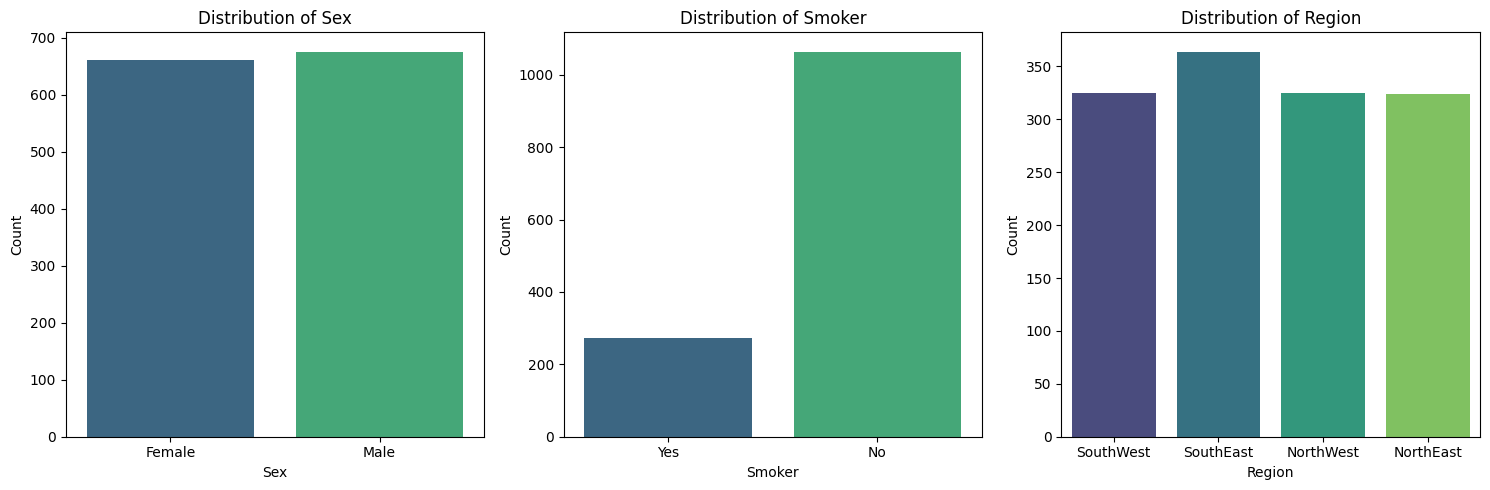

In [75]:
# Visualize the distribution of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

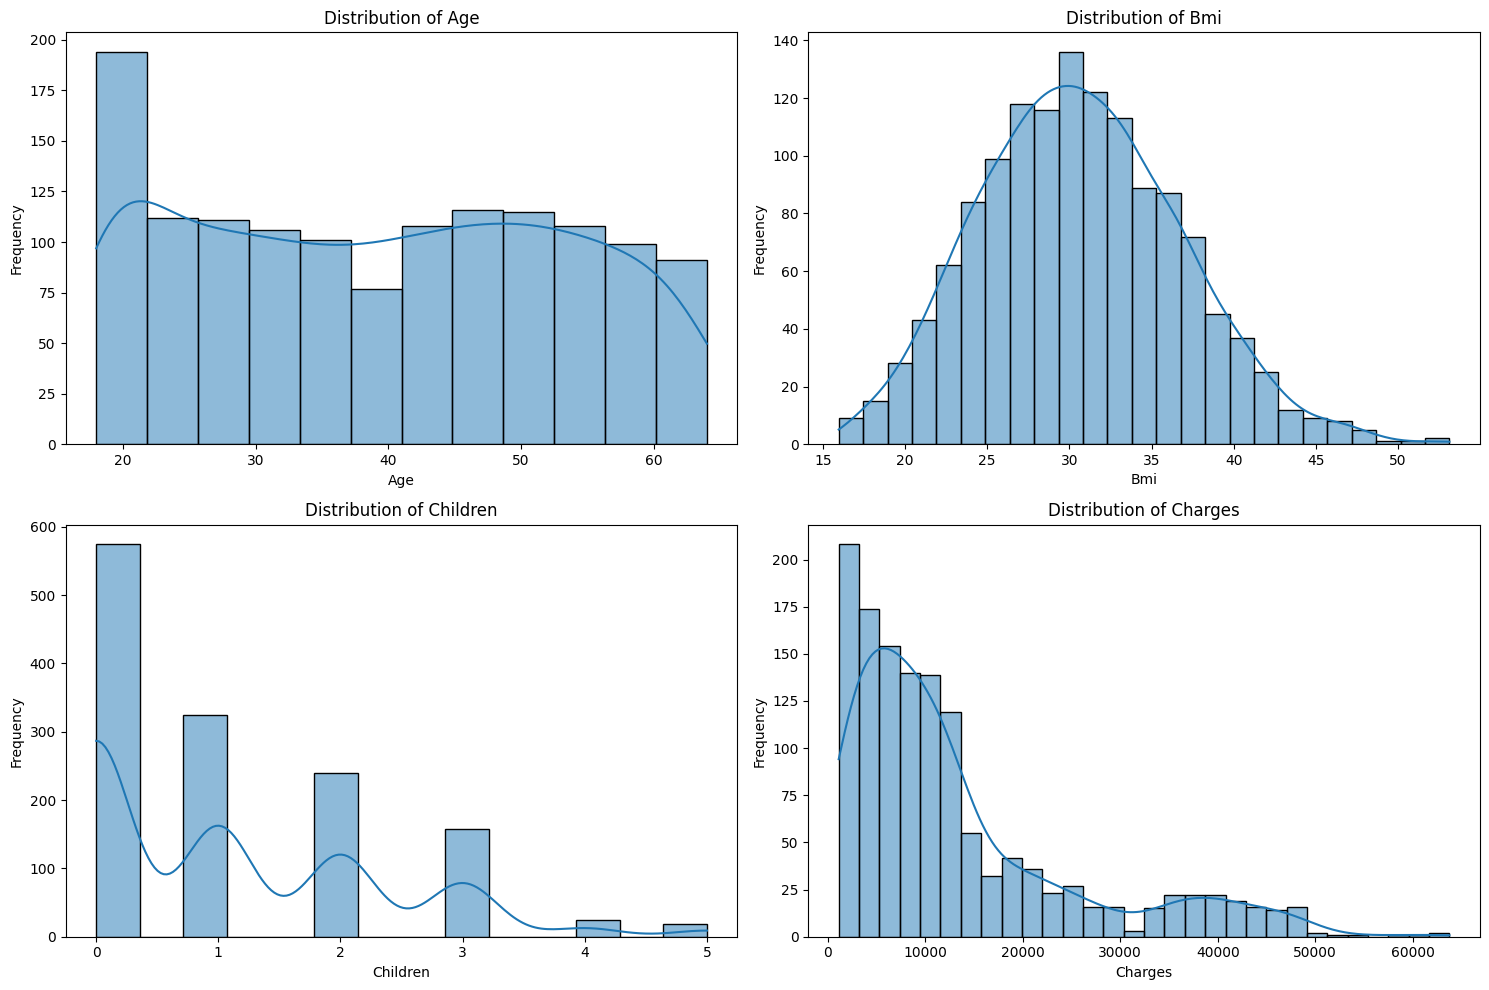

In [76]:
# Visualize the distribution of numerical variables
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

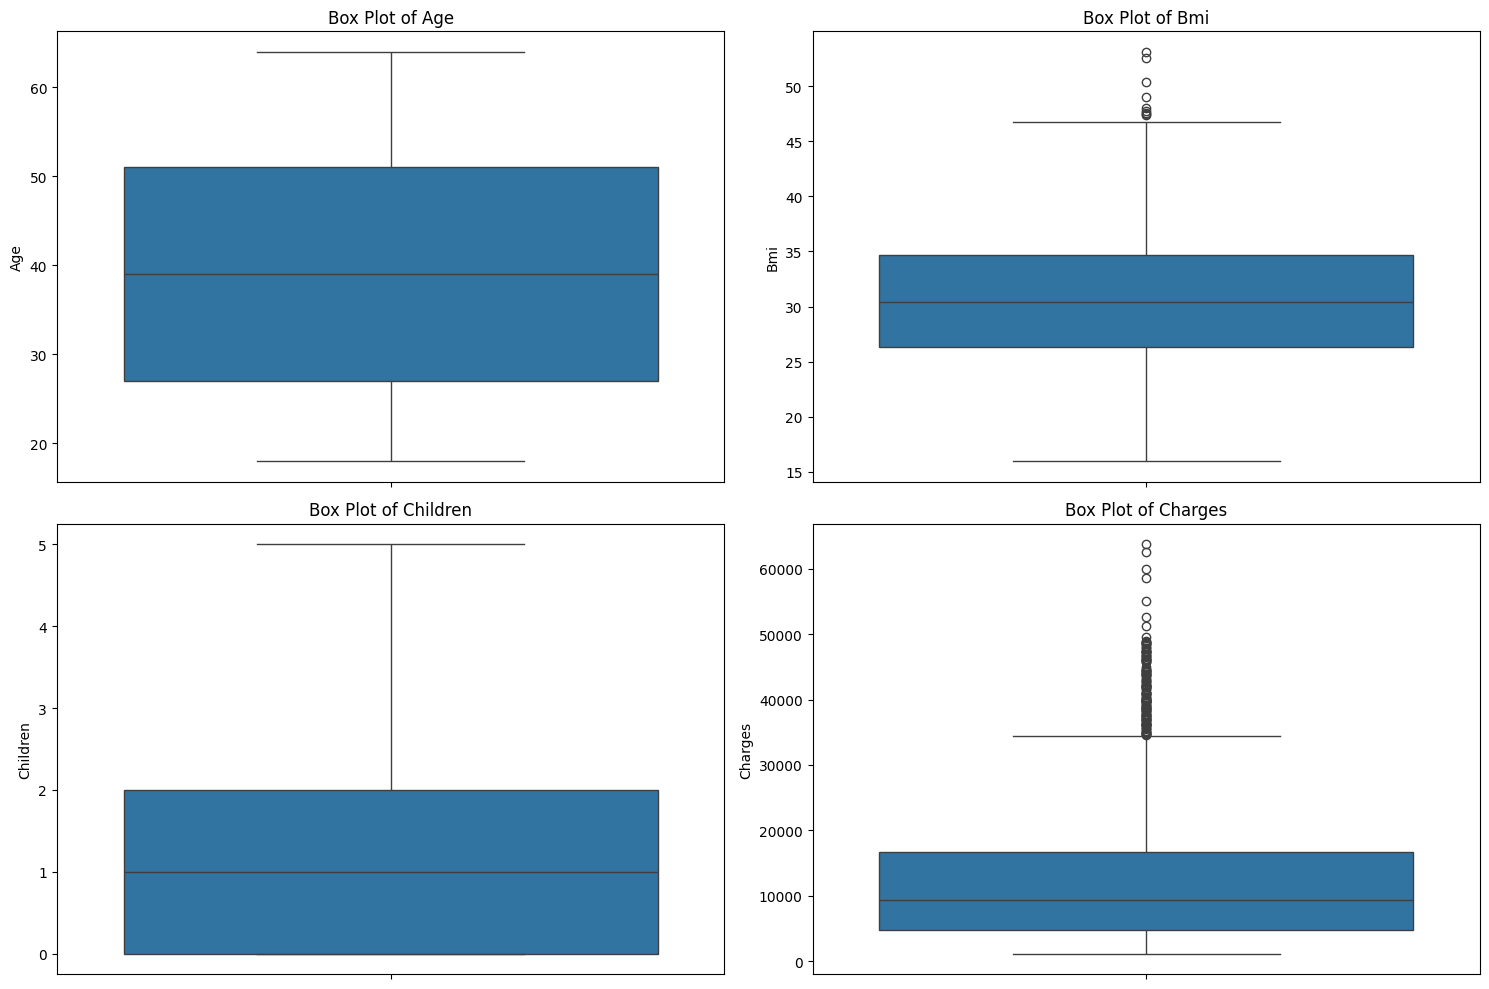

In [77]:
# Visualize the box plots for numerical variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [78]:
# convert categorical to numeric
label_encoders = {}

for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])
    print({label: index for index, label in enumerate(label_encoders[col].classes_)})

{'Female': 0, 'Male': 1}
{'No': 0, 'Yes': 1}
{'NorthEast': 0, 'NorthWest': 1, 'SouthEast': 2, 'SouthWest': 3}


In [ ]:
# convert categorical to numeric using one-hot encoding
#df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

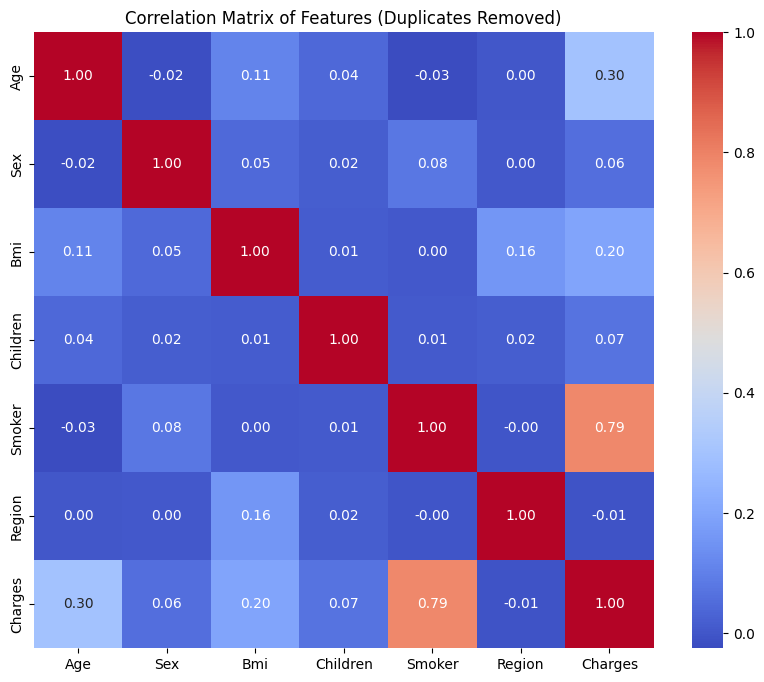

In [79]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features (Duplicates Removed)')
plt.show()

In [80]:
#df = pd.get_dummies(df, columns=categorical_cols, dtype=np.int64, drop_first=True)
df.skew()

Age         0.055673
Sex        -0.020951
Bmi         0.284047
Children    0.938380
Smoker      1.464766
Region     -0.038101
Charges     1.515880
dtype: float64

#### Observations :
##### i. The dataset contains 1337 unique entries after removing one duplicate row, with no missing values.
##### ii. Number of data entries for different Sex & Region classes are balanced.
##### iii. More data entries for non-smoker individuals.
##### iv. Distribution of Children & Charges are right skewed.
##### v. Few outliers in BMI & Charges.
##### vi. Smoker has highest positive corelation with insurance changes (0.79), followed by Age (0.30) & BMI (0.20)  

#### Function to evaluate model performance

In [81]:
training_r2_scores = []
testing_r2_scores = []
training_adj_r2_scores = []
testing_adj_r2_scores = []
training_rmse_scores = []
testing_rmse_scores = []
training_mae_scores = []
testing_mae_scores = []

def ClearMetrics():
    training_r2_scores.clear()
    testing_r2_scores.clear()
    training_adj_r2_scores.clear()
    testing_adj_r2_scores.clear()
    training_rmse_scores.clear()
    testing_rmse_scores.clear()
    training_mae_scores.clear()
    testing_mae_scores.clear()

def EvaluateModel(p_model, p_x_train, p_y_train, p_x_test, p_y_test):
    p_model.fit(p_x_train, p_y_train)
    
    y_train_pred = p_model.predict(p_x_train)
    train_mse = mean_squared_error(p_y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(p_y_train, y_train_pred)
    train_r2 = r2_score(p_y_train, y_train_pred)
    train_adj_r2 = 1 - (1 - train_r2) * (len(p_y_train) - 1) / (len(p_y_train) - p_x_train.shape[1] - 1)

    y_test_pred = p_model.predict(p_x_test)
    test_mse = mean_squared_error(p_y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(p_y_test, y_test_pred)
    test_r2 = r2_score(p_y_test, y_test_pred)
    test_adj_r2 = 1 - (1 - test_r2) * (len(p_y_test) - 1) / (len(p_y_test) - p_x_test.shape[1] - 1)

    training_r2_scores.append(np.round(train_r2, 4))
    testing_r2_scores.append(np.round(test_r2, 4))
    training_adj_r2_scores.append(np.round(train_adj_r2, 4))
    testing_adj_r2_scores.append(np.round(test_adj_r2, 4))
    training_rmse_scores.append(np.round(train_rmse, 4))
    testing_rmse_scores.append(np.round(test_rmse, 4))
    training_mae_scores.append(np.round(train_mae, 4))
    testing_mae_scores.append(np.round(test_mae, 4))

In [82]:
def EndToEndEvaluation(p_models, p_x_train, p_y_train, p_x_test, p_y_test):
    ClearMetrics()
    for l_model in p_models:
        EvaluateModel(l_model, p_x_train, p_y_train, p_x_test, p_y_test)

    results_df = pd.DataFrame({
        'Model': [model.__class__.__name__ for model in p_models],
        'Train R2': training_r2_scores,
        'Test R2': testing_r2_scores,
        'Train Adjusted R2': training_adj_r2_scores,
        'Test Adjusted R2': testing_adj_r2_scores,
        'Train RMSE': training_rmse_scores,
        'Test RMSE': testing_rmse_scores,
        'Train MAE': training_mae_scores,
        'Test MAE': testing_mae_scores
    })

    results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
    return results_df

In [83]:
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    SVR(),
    KNeighborsRegressor(),
    GradientBoostingRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    XGBRegressor(random_state=42),
    VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('svr', SVR()),
        ('knn', KNeighborsRegressor()),
        ('rf', RandomForestRegressor(random_state=42))
    ])
]

#### Evaluate without EDA

In [84]:
df_without_eda = df.copy()

x = df_without_eda.drop(columns=['Charges'])
y = df_without_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation without EDA :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation without EDA :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,GradientBoostingRegressor,0.8980,0.8780,0.8975,0.8752,3836.0650,4352.5389,2101.3617,2447.9516
1,RandomForestRegressor,0.9743,0.8643,0.9742,0.8611,1925.6241,4590.5735,1053.5887,2533.6746
2,XGBRegressor,0.9941,0.8502,0.9941,0.8467,919.7656,4822.9912,499.3392,2791.8325
3,AdaBoostRegressor,0.8146,0.8213,0.8135,0.8172,5173.0364,5267.0605,4258.3126,4421.2593
4,Lasso,0.7417,0.7833,0.7402,0.7783,6105.7903,5799.9430,4209.1351,4187.2449
5,LinearRegression,0.7417,0.7833,0.7402,0.7784,6105.7893,5799.5871,4208.7620,4186.5089
6,Ridge,0.7417,0.7831,0.7402,0.7781,6106.0333,5803.0847,4218.4315,4198.1410
7,DecisionTreeRegressor,0.9983,0.6844,0.9983,0.6771,494.2060,7000.2317,29.5725,3154.7057
8,VotingRegressor,0.7139,0.6617,0.7123,0.6540,6425.8229,7246.6767,4192.4649,4910.3544
9,ElasticNet,0.3832,0.4193,0.3797,0.4059,9435.1831,9495.1877,7282.6956,7426.0595


#### Perform EDA

In [99]:
df_eda = df.copy()

In [100]:
df_eda.skew()

Age         0.055673
Sex        -0.020951
Bmi         0.284047
Children    0.938380
Smoker      1.464766
Region     -0.038101
Charges     1.515880
dtype: float64

In [101]:
df_eda['Children'] = np.log1p(df_eda['Children'])
df_eda['Charges'] = np.log1p(df_eda['Charges'])

In [102]:
df_eda.skew()

Age         0.055673
Sex        -0.020951
Bmi         0.284047
Children    0.264083
Smoker      1.464766
Region     -0.038101
Charges    -0.089817
dtype: float64

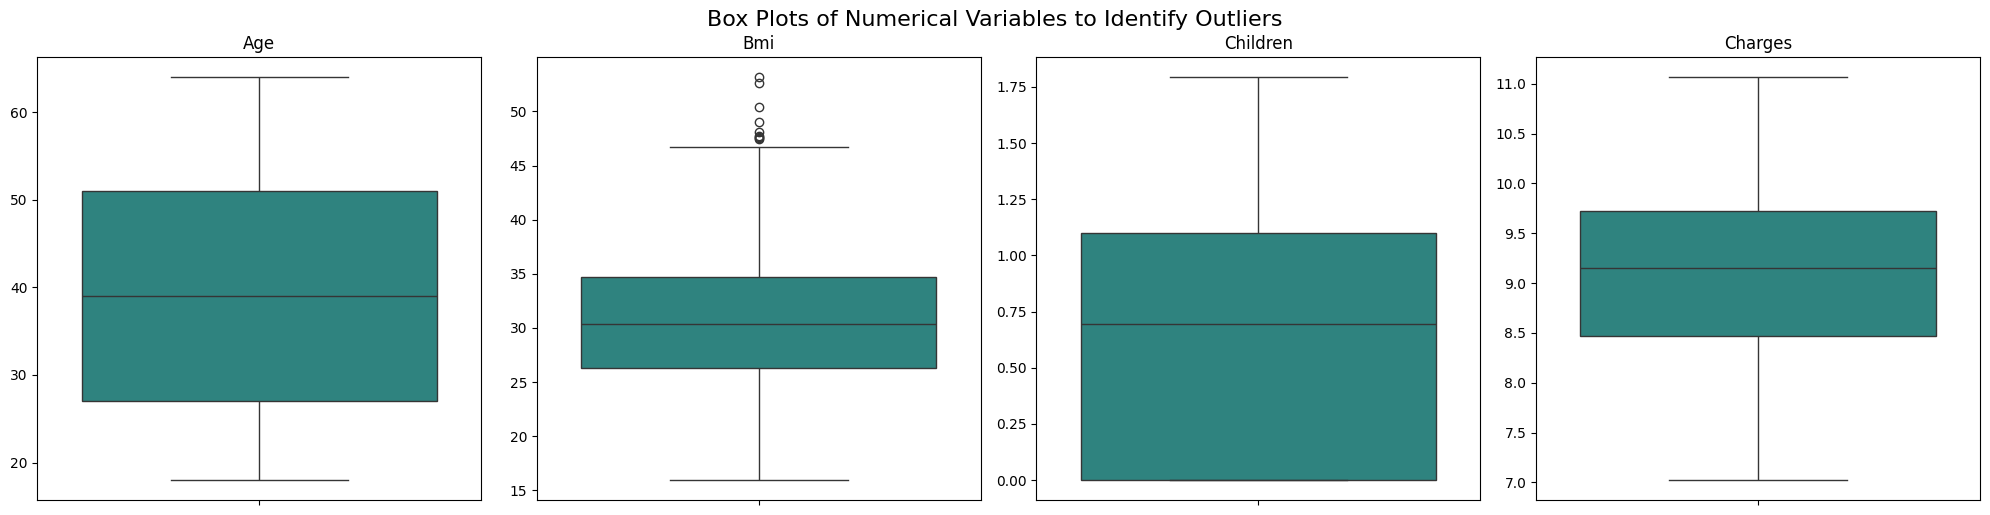

In [103]:
# outlier detection

predictors = [col for col in df_eda.columns if col not in categorical_cols]
num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [104]:
def handle_outliers_iqr(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    mean = int(p_df[p_column].mean())
    print(p_column , " : lower_bound : ", lower_bound , ", upper_bound : ", upper_bound, ", mean :", mean)

    #capping values outside the bounds
    p_df[p_column] = np.where((p_df[p_column] < lower_bound), lower_bound, p_df[p_column])
    p_df[p_column] = np.where((p_df[p_column] > upper_bound), upper_bound, p_df[p_column])

#Handling outliers by capping them using IQR method
for col in predictors:
    handle_outliers_iqr(df_eda, col)

Age  : lower_bound :  -9.0 , upper_bound :  87.0 , mean : 39
Bmi  : lower_bound :  13.7 , upper_bound :  47.290000000000006 , mean : 30
Children  : lower_bound :  -1.6479184330021646 , upper_bound :  2.7465307216702746 , mean : 0
Charges  : lower_bound :  6.580732393758863 , upper_bound :  11.60294909473525 , mean : 9


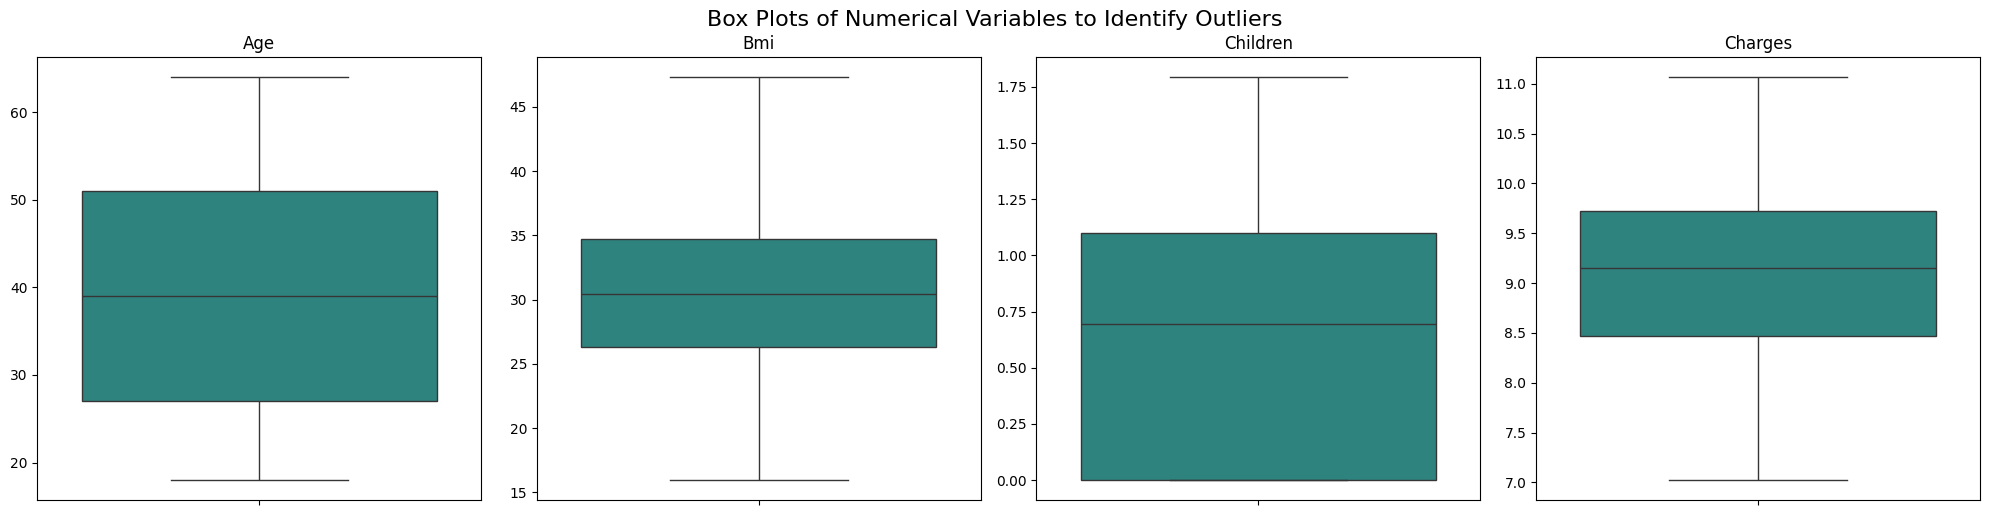

In [105]:
# distribution post outlier detection

num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [106]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1338.0,39.207025,14.049960,18.000000,27.000000,39.000000,51.000000,64.000000
Sex,1338.0,0.505232,0.500160,0.000000,0.000000,1.000000,1.000000,1.000000
Bmi,1338.0,30.650034,6.056926,15.960000,26.296250,30.400000,34.693750,47.290000
Children,1338.0,0.581751,0.558325,0.000000,0.000000,0.693147,1.098612,1.791759
Smoker,1338.0,0.204783,0.403694,0.000000,0.000000,0.000000,0.000000,1.000000
Region,1338.0,1.515695,1.104885,0.000000,1.000000,2.000000,2.000000,3.000000
Charges,1338.0,9.098828,0.919379,7.023647,8.464064,9.146658,9.719618,11.063061


In [107]:
x = df_eda.drop(columns=['Charges'])
y = df_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & without scaling :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & without scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,GradientBoostingRegressor,0.8822,0.8654,0.8816,0.8623,0.3126,0.3478,0.1650,0.1842
1,RandomForestRegressor,0.9682,0.8510,0.9680,0.8475,0.1624,0.3660,0.0798,0.1826
2,XGBRegressor,0.9898,0.8262,0.9897,0.8222,0.0921,0.3953,0.0416,0.2063
3,LinearRegression,0.7576,0.8035,0.7562,0.7990,0.4486,0.4202,0.2854,0.2746
4,Ridge,0.7575,0.8034,0.7562,0.7989,0.4486,0.4203,0.2857,0.2753
5,DecisionTreeRegressor,0.9945,0.7818,0.9944,0.7768,0.0677,0.4429,0.0041,0.1904
6,AdaBoostRegressor,0.7718,0.7614,0.7705,0.7559,0.4352,0.4631,0.3248,0.3497
7,VotingRegressor,0.7639,0.7539,0.7625,0.7482,0.4427,0.4703,0.2878,0.3136
8,KNeighborsRegressor,0.5037,0.4401,0.5009,0.4272,0.6418,0.7094,0.4616,0.5209
9,SVR,0.2513,0.3985,0.2471,0.3847,0.7883,0.7353,0.4666,0.4358


In [108]:
#use scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,GradientBoostingRegressor,0.8822,0.8654,0.8816,0.8623,0.3126,0.3478,0.1650,0.1842
1,SVR,0.8371,0.8645,0.8362,0.8614,0.3677,0.3490,0.1658,0.1558
2,VotingRegressor,0.8904,0.8606,0.8898,0.8574,0.3015,0.3540,0.1619,0.1905
3,RandomForestRegressor,0.9683,0.8520,0.9681,0.8486,0.1623,0.3647,0.0796,0.1818
4,XGBRegressor,0.9898,0.8262,0.9897,0.8222,0.0921,0.3953,0.0416,0.2063
5,LinearRegression,0.7576,0.8035,0.7562,0.7990,0.4486,0.4202,0.2854,0.2746
6,Ridge,0.7576,0.8035,0.7562,0.7990,0.4486,0.4203,0.2855,0.2748
7,KNeighborsRegressor,0.8554,0.8014,0.8546,0.7968,0.3464,0.4225,0.2090,0.2599
8,DecisionTreeRegressor,0.9945,0.7905,0.9944,0.7857,0.0677,0.4339,0.0041,0.1850
9,AdaBoostRegressor,0.7718,0.7614,0.7705,0.7559,0.4352,0.4631,0.3248,0.3497


In [109]:
# Calculate VIF for each feature
vif1 = df_eda.copy()
vif1.drop(columns=['Charges'], inplace=True)

variable1 = vif1
vif_data1 = pd.DataFrame()
vif_data1['Variance Inflation Factor'] = [variance_inflation_factor(variable1, i) for i in range(variable1.shape[1])]
vif_data1['Features'] = vif1.columns

vif_data1.sort_values(by="Variance Inflation Factor", ascending=False)

,Variance Inflation Factor,Features
2,10.535688,Bmi
0,7.606973,Age
5,2.925411,Region
3,2.050587,Children
1,2.000680,Sex
4,1.257224,Smoker


#### Observation : GradientBoostingRegressor is best performing model with : Train R2 : 0.8822 , Test_R2 : 0.8654 , Train_RMSE : 0.3126 , Test_RMSE : 0.3478

In [ ]:
best_performing_model = models[8]

l_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

x = df_eda.drop(columns=['Charges'])
y = df_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
grid_search = GridSearchCV(estimator=best_performing_model, param_grid=l_param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_scaled, y_train)

best_model_GSCV = grid_search.best_estimator_
print("Best Hyperparameters for GradientBoostingRegressor model:", grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters for XGBClassifier model: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 50}


In [113]:
l_models = [best_model_GSCV]
print("Best Model evaluation with EDA & scaling (GridSearchCV) :")
EndToEndEvaluation(l_models, x_train_scaled, y_train, x_test_scaled, y_test)

Best Model evaluation with EDA & scaling (GridSearchCV) :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,GradientBoostingRegressor,0.8577,0.8658,0.8569,0.8628,0.3436,0.3473,0.1818,0.1876


#### Best Hyperparameters for GradientBoostingRegressor model: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 50}

#### Pre hyperparameter tuning :	Train R2 : 0.8822 , Test_R2 : 0.8654 , Train_RMSE : 0.3126 , Test_RMSE : 0.3478
#### Post hyperparameter tuning :	Train R2 : 0.8577 ,	Test R2 : 0.8658 , Train RMSE : 0.3436 , Test RMSE : 0.3473

In [114]:
#dump the best performing model
joblib.dump(best_model_GSCV, 'GradientBoostingRegressor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [115]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1338 non-null   float64
 1   Sex       1338 non-null   int64  
 2   Bmi       1338 non-null   float64
 3   Children  1338 non-null   float64
 4   Smoker    1338 non-null   int64  
 5   Region    1338 non-null   int64  
 6   Charges   1338 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 73.3 KB
